In [3]:
from pathlib import Path
import os

project_folder = Path(
    r"C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2"
)

os.chdir(project_folder)

csv_path = Path("data") / "Metro_Interstate_Traffic_Volume.csv"

print("작업 폴더:", Path.cwd())
print("CSV 파일 확인:", csv_path.is_file())

작업 폴더: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2
CSV 파일 확인: True


In [5]:
%%writefile pipeline.py
from pathlib import Path
import logging
import pandas as pd

logger = logging.getLogger(__name__)

BASE_DIR = Path(__file__).resolve().parent

EXPECTED_COLUMNS = [
    "holiday", "temp", "rain_1h", "snow_1h", "clouds_all",
    "weather_main", "weather_description",
    "date_time", "traffic_volume"
]


def configure_logging():
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
    )
    logger.setLevel(logging.INFO)
    logger.propagate = False

    for handler in logger.handlers[:]:
        handler.close()
        logger.removeHandler(handler)

    console_handler = logging.StreamHandler()
    file_handler = logging.FileHandler(
        BASE_DIR / "pipeline.log",
        mode="a",
        encoding="utf-8"
    )

    for handler in (console_handler, file_handler):
        handler.setFormatter(formatter)
        logger.addHandler(handler)


def load_and_validate(csv_path):
    # Preserve the literal holiday value "None".
    df = pd.read_csv(csv_path, keep_default_na=False)

    logger.info(
        "Loaded CSV: %s | rows=%d | columns=%d",
        csv_path.name, df.shape[0], df.shape[1]
    )

    # Validate the schema before cleaning or transforming data.
    missing_columns = [
        column for column in EXPECTED_COLUMNS
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    logger.info("Schema validation passed: all 9 required columns exist")
    return df


def main():
    configure_logging()
    csv_path = BASE_DIR / "data" / "Metro_Interstate_Traffic_Volume.csv"

    try:
        df = load_and_validate(csv_path)
        logger.info(
            "Loading and validation completed: %d records",
            len(df)
        )
        return 0

    except (OSError, ValueError, pd.errors.ParserError) as exc:
        logger.error(
            "Pipeline failed: %s", exc, exc_info=True
        )
        return 1


if __name__ == "__main__":
    raise SystemExit(main())

Overwriting pipeline.py


In [6]:
%run pipeline.py

2026-10-10 19:51:25,500 | INFO | __main__ | Loaded CSV: Metro_Interstate_Traffic_Volume.csv | rows=48204 | columns=9
2026-10-10 19:51:25,512 | INFO | __main__ | Schema validation passed: all 9 required columns exist
2026-10-10 19:51:25,513 | INFO | __main__ | Loading and validation completed: 48204 records


In [7]:
%%writefile pipeline.py
from pathlib import Path
import logging
import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)
BASE_DIR = Path(__file__).resolve().parent

EXPECTED_COLUMNS = [
    "holiday", "temp", "rain_1h", "snow_1h", "clouds_all",
    "weather_main", "weather_description",
    "date_time", "traffic_volume"
]


def configure_logging():
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
    )
    logger.setLevel(logging.INFO)
    logger.propagate = False

    for handler in logger.handlers[:]:
        handler.close()
        logger.removeHandler(handler)

    handlers = [
        logging.StreamHandler(),
        logging.FileHandler(
            BASE_DIR / "pipeline.log",
            mode="a",
            encoding="utf-8"
        )
    ]

    for handler in handlers:
        handler.setFormatter(formatter)
        logger.addHandler(handler)


def log_change(count, reason):
    if count:
        logger.warning("Affected rows=%d | %s", count, reason)
    else:
        logger.info("Affected rows=0 | %s", reason)


def load_and_validate(csv_path):
    df = pd.read_csv(csv_path, keep_default_na=False)
    logger.info(
        "Loaded CSV: rows=%d | columns=%d",
        *df.shape
    )

    missing = [
        column for column in EXPECTED_COLUMNS
        if column not in df.columns
    ]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if df.empty:
        raise ValueError("The CSV contains no records")

    logger.info("Schema validation passed")
    return df


def clean_data(df):
    df = df.copy()

    # Standardise text while preserving the holiday label "None".
    for column in ["holiday", "weather_main", "weather_description"]:
        original = df[column].astype("string")
        cleaned = (
            original.str.strip()
            .str.replace(r"\s+", " ", regex=True)
            .str.lower()
            .fillna("unknown")
            .replace("", "unknown")
        )
        changed = int(original.ne(cleaned).fillna(True).sum())
        df[column] = cleaned
        log_change(changed, f"Standardised text in {column}")

    # Parse dates and remove unusable timestamps.
    df["date_time"] = pd.to_datetime(
        df["date_time"],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )
    invalid_dates = df["date_time"].isna()
    log_change(int(invalid_dates.sum()), "Dropped invalid dates")
    df = df.loc[~invalid_dates].copy()

    # Convert numerical columns; invalid entries become missing.
    numeric_columns = [
        "temp", "rain_1h", "snow_1h",
        "clouds_all", "traffic_volume"
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
        df[column] = df[column].replace(
            [np.inf, -np.inf], np.nan
        )
        log_change(
            int(df[column].isna().sum()),
            f"Missing or invalid numerical values in {column}"
        )

    # Remove exact duplicates, not all repeated timestamps.
    duplicates = df.duplicated(subset=EXPECTED_COLUMNS)
    log_change(int(duplicates.sum()), "Removed exact duplicate rows")
    df = df.loc[~duplicates].copy()

    # Do not invent missing traffic targets.
    invalid_target = (
        df["traffic_volume"].isna()
        | (df["traffic_volume"] < 0)
        | (df["traffic_volume"] % 1 != 0)
    )
    log_change(
        int(invalid_target.sum()),
        "Dropped missing, negative or non-integer traffic targets"
    )
    df = df.loc[~invalid_target].copy()

    if df.empty:
        raise ValueError("No usable records remain")

    # Broad validation rules, including the assignment's rain threshold.
    invalid_rules = {
        "temp": df["temp"] <= 0,
        "rain_1h": (df["rain_1h"] < 0) | (df["rain_1h"] > 9000),
        "snow_1h": df["snow_1h"] < 0,
        "clouds_all": ~df["clouds_all"].between(0, 100)
    }

    for column, invalid in invalid_rules.items():
        affected = invalid | df[column].isna()
        log_change(
            int(affected.sum()),
            f"Flagged missing or impossible values in {column}"
        )
        df.loc[affected, column] = np.nan

        valid_values = df[column].dropna()
        if valid_values.empty:
            raise ValueError(f"No valid values available for {column}")

        fallback_median = valid_values.median()

        # Use the median for each calendar month across available years.
        for month in sorted(df["date_time"].dt.month.unique()):
            month_mask = df["date_time"].dt.month == month
            to_fill = month_mask & df[column].isna()
            count = int(to_fill.sum())

            if count:
                monthly_median = df.loc[month_mask, column].median()

                if pd.isna(monthly_median):
                    monthly_median = fallback_median
                    method = "global median fallback"
                else:
                    method = "calendar-month median"

                df.loc[to_fill, column] = monthly_median
                logger.warning(
                    "Imputed rows=%d | column=%s | month=%d | "
                    "method=%s | value=%.4f",
                    count, column, month, method, monthly_median
                )

    df["traffic_volume"] = df["traffic_volume"].astype("int64")
    df = df.sort_values("date_time").reset_index(drop=True)

    logger.info(
        "Repeated timestamp rows retained=%d; "
        "different weather records can share a timestamp",
        int(df["date_time"].duplicated().sum())
    )
    logger.info(
        "Cleaning completed: rows=%d | columns=%d",
        *df.shape
    )
    return df


def main():
    configure_logging()

    try:
        csv_path = (
            BASE_DIR / "data" / "Metro_Interstate_Traffic_Volume.csv"
        )
        df = load_and_validate(csv_path)
        cleaned = clean_data(df)

        output_folder = BASE_DIR / "data" / "processed"
        output_folder.mkdir(parents=True, exist_ok=True)
        output_path = output_folder / "traffic_cleaned.csv"

        cleaned.to_csv(output_path, index=False)
        logger.info("Saved cleaned dataset: %s", output_path)
        return 0

    except (OSError, ValueError, pd.errors.ParserError) as exc:
        logger.error("Pipeline failed: %s", exc, exc_info=True)
        return 1


if __name__ == "__main__":
    raise SystemExit(main())

Overwriting pipeline.py


In [8]:
%run pipeline.py

2026-10-10 20:14:42,233 | INFO | __main__ | Loaded CSV: rows=48204 | columns=9
2026-10-10 20:14:42,237 | INFO | __main__ | Schema validation passed
2026-10-10 20:14:42,470 | WARNING | __main__ | Affected rows=48204 | Standardised text in holiday
2026-10-10 20:14:42,558 | WARNING | __main__ | Affected rows=48204 | Standardised text in weather_main
2026-10-10 20:14:42,675 | WARNING | __main__ | Affected rows=1730 | Standardised text in weather_description
2026-10-10 20:14:42,748 | INFO | __main__ | Affected rows=0 | Dropped invalid dates
2026-10-10 20:14:42,805 | INFO | __main__ | Affected rows=0 | Missing or invalid numerical values in temp
2026-10-10 20:14:42,809 | INFO | __main__ | Affected rows=0 | Missing or invalid numerical values in rain_1h
2026-10-10 20:14:42,813 | INFO | __main__ | Affected rows=0 | Missing or invalid numerical values in snow_1h
2026-10-10 20:14:42,817 | INFO | __main__ | Affected rows=0 | Missing or invalid numerical values in clouds_all
2026-10-10 20:14:42,82

In [9]:
%%writefile feature_engineering.py
from pathlib import Path
import argparse
import json
import logging

import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)
BASE_DIR = Path(__file__).resolve().parent


def create_features(df):
    logger.info("Before feature engineering: rows=%d | columns=%d", *df.shape)
    df = df.copy()

    df["date_time"] = pd.to_datetime(df["date_time"], errors="raise")
    if df.empty or df["date_time"].isna().any():
        raise ValueError("Empty dataset or missing timestamps")

    # Time features: Monday=0, Sunday=6.
    df["hour"] = df["date_time"].dt.hour
    df["day_of_week"] = df["date_time"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Cyclical encoding preserves the connection between 23:00 and 00:00.
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    # Propagate a holiday label to all observed hours of that date.
    dates = df["date_time"].dt.normalize()
    labelled = ~df["holiday"].str.lower().isin(["none", "unknown", ""])
    holiday_dates = dates[labelled].unique()
    df["is_holiday"] = dates.isin(holiday_dates).astype(int)

    # Weather features.
    df["temperature_c"] = df["temp"] - 273.15
    df["is_raining"] = (df["rain_1h"] > 0).astype(int)
    df["is_snowing"] = (df["snow_1h"] > 0).astype(int)

    weather_columns = pd.get_dummies(
        df["weather_main"],
        prefix="weather",
        dtype=int
    )
    df = pd.concat([df, weather_columns], axis=1)

    # Scale two continuous variables for Part 2 exploration.
    scaling = {}
    for column in ["temp", "rain_1h"]:
        minimum = float(df[column].min())
        maximum = float(df[column].max())
        span = maximum - minimum

        df[f"{column}_scaled"] = (
            (df[column] - minimum) / span if span > 0 else 0.0
        )
        scaling[column] = {"min": minimum, "max": maximum}
        logger.debug(
            "Scaling %s: min=%.4f | max=%.4f",
            column, minimum, maximum
        )

    # Data-driven target categories, based on traffic quartiles.
    q1, q2, q3 = df["traffic_volume"].quantile([0.25, 0.50, 0.75])
    df["congestion_category"] = np.select(
        [
            df["traffic_volume"] <= q1,
            df["traffic_volume"] <= q2,
            df["traffic_volume"] <= q3
        ],
        ["Low", "Moderate", "High"],
        default="Severe"
    )
    logger.debug(
        "Traffic quartiles: Q1=%.2f | Q2=%.2f | Q3=%.2f",
        q1, q2, q3
    )

    metadata = {
        "scaling": scaling,
        "traffic_quartiles": {
            "q1": float(q1),
            "q2": float(q2),
            "q3": float(q3)
        },
        "category_rule": (
            "Low <= Q1; Moderate > Q1 and <= Q2; "
            "High > Q2 and <= Q3; Severe > Q3"
        ),
        "scope": (
            "Part 2 exploratory features fitted on the cleaned dataset. "
            "For Part 3, fit learned preprocessing on training data only. "
            "Do not use traffic_volume or congestion_category as predictors "
            "of traffic_volume."
        )
    }

    logger.info("After feature engineering: rows=%d | columns=%d", *df.shape)
    return df, metadata


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--debug", action="store_true")
    args = parser.parse_args()

    # Configure handlers only when this script is the entry point.
    logging.basicConfig(
        level=logging.DEBUG if args.debug else logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        handlers=[
            logging.StreamHandler(),
            logging.FileHandler(
                BASE_DIR / "pipeline.log", mode="a", encoding="utf-8"
            )
        ],
        force=True
    )

    try:
        folder = BASE_DIR / "data" / "processed"
        df = pd.read_csv(
            folder / "traffic_cleaned.csv",
            keep_default_na=False
        )
        featured, metadata = create_features(df)

        output_path = folder / "traffic_features.csv"
        featured.to_csv(output_path, index=False)
        logger.info("Saved feature dataset: %s", output_path)

        metadata_path = folder / "feature_metadata.json"
        metadata_path.write_text(
            json.dumps(metadata, indent=2),
            encoding="utf-8"
        )
        logger.info("Saved feature definitions: %s", metadata_path)
        return 0

    except (OSError, ValueError, KeyError, TypeError) as exc:
        logger.error("Feature engineering failed: %s", exc, exc_info=True)
        return 1


if __name__ == "__main__":
    raise SystemExit(main())

Writing feature_engineering.py


In [10]:
%run feature_engineering.py

2026-10-10 20:29:56,000 | INFO | __main__ | Before feature engineering: rows=48187 | columns=9
2026-10-10 20:29:56,245 | INFO | __main__ | After feature engineering: rows=48187 | columns=34
2026-10-10 20:29:57,482 | INFO | __main__ | Saved feature dataset: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2\data\processed\traffic_features.csv
2026-10-10 20:29:57,509 | INFO | __main__ | Saved feature definitions: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2\data\processed\feature_metadata.json


In [11]:
%%writefile visualizations.py
from pathlib import Path
import logging

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)
BASE_DIR = Path(__file__).resolve().parent


def save_figure(fig, folder, filename):
    path = folder / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    logger.info("Saved figure: %s", path)


def create_visualizations(df, output_folder):
    required = {"date_time", "traffic_volume", "temperature_c"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    if df.empty:
        raise ValueError("The dataset is empty")

    df = df.copy()
    df["date_time"] = pd.to_datetime(df["date_time"], errors="raise")

    if df[list(required)].isna().any().any():
        raise ValueError("Missing values in required chart columns")

    output_folder.mkdir(parents=True, exist_ok=True)

    # Give each observed timestamp equal weight.
    hourly = (
        df.groupby("date_time", as_index=False)
        .agg(
            traffic_volume=("traffic_volume", "mean"),
            temperature_c=("temperature_c", "mean")
        )
    )
    hourly["hour"] = hourly["date_time"].dt.hour
    hourly["is_weekend"] = (
        hourly["date_time"].dt.dayofweek >= 5
    ).astype(int)

    logger.info(
        "Prepared charts from %d records and %d distinct timestamps",
        len(df), len(hourly)
    )

    # Chart 1: Average traffic by hour.
    by_hour = (
        hourly.groupby("hour")["traffic_volume"]
        .mean()
        .reindex(range(24))
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(by_hour.index, by_hour.values, color="#2878B5")
    ax.set(
        title="Average Traffic by Hour",
        xlabel="Hour of day",
        ylabel="Average traffic volume (vehicles)"
    )
    ax.set_xticks(range(24))
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    save_figure(fig, output_folder, "01_traffic_by_hour.png")

    # Chart 2: Weekday and weekend hourly patterns.
    comparison = (
        hourly.groupby(["hour", "is_weekend"])["traffic_volume"]
        .mean()
        .unstack("is_weekend")
        .reindex(index=range(24), columns=[0, 1])
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    for value, label, color in [
        (0, "Weekday", "#2878B5"),
        (1, "Weekend", "#D97706")
    ]:
        ax.plot(
            comparison.index,
            comparison[value],
            marker="o",
            label=label,
            color=color
        )

    ax.set(
        title="Hourly Traffic on Weekdays and Weekends",
        xlabel="Hour of day",
        ylabel="Average traffic volume (vehicles)"
    )
    ax.set_xticks(range(24))
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(alpha=0.25)
    save_figure(fig, output_folder, "02_weekday_weekend.png")

    # Chart 3: Temperature and traffic.
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(
        hourly["temperature_c"],
        hourly["traffic_volume"],
        s=7,
        alpha=0.12,
        color="#2878B5",
        edgecolors="none"
    )
    ax.set(
        title="Temperature and Traffic Volume",
        xlabel="Temperature (°C)",
        ylabel="Traffic volume (vehicles)"
    )
    ax.grid(alpha=0.2)
    save_figure(fig, output_folder, "03_temperature_traffic.png")

    # Save short interpretations using the calculated results.
    peak_hour = int(by_hour.idxmax())
    quiet_hour = int(by_hour.idxmin())
    day_means = hourly.groupby("is_weekend")["traffic_volume"].mean()
    correlation = hourly["temperature_c"].corr(hourly["traffic_volume"])

    notes = (
        "# Traffic visualisation findings\n\n"
        "Scope: all available years in the cleaned dataset. "
        "Records are averaged by timestamp before plotting, so each "
        "observed timestamp has equal weight. Missing hours are not "
        "filled with zero.\n\n"
        "## 1. Average traffic by hour\n"
        f"The highest hourly mean occurs at {peak_hour:02d}:00 "
        f"({by_hour.loc[peak_hour]:,.2f} vehicles), and the lowest at "
        f"{quiet_hour:02d}:00 ({by_hour.loc[quiet_hour]:,.2f} vehicles). "
        "These differences support time-specific mobility planning.\n\n"
        "## 2. Weekday and weekend patterns\n"
        f"Average traffic is {day_means.get(0, float('nan')):,.2f} "
        "vehicles on weekdays and "
        f"{day_means.get(1, float('nan')):,.2f} on weekends. "
        "The hourly curves allow comparison at similar times of day. "
        "Unequal coverage and holidays may influence these averages.\n\n"
        "## 3. Temperature and traffic\n"
        f"The Pearson correlation for the cleaned, timestamp-averaged "
        f"data is {correlation:.3f}. "
        "The scatter shows whether similar temperatures coincide with "
        "different traffic volumes. This association does not establish "
        "causation because time of day and season may influence both "
        "variables. This calculation uses a different preparation method "
        "from the raw-record correlation in Part 1.\n"
    )

    notes_path = output_folder / "visualization_notes.md"
    notes_path.write_text(notes, encoding="utf-8")
    logger.info("Saved chart interpretations: %s", notes_path)


def main():
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        handlers=[
            logging.StreamHandler(),
            logging.FileHandler(
                BASE_DIR / "pipeline.log",
                mode="a",
                encoding="utf-8"
            )
        ],
        force=True
    )

    try:
        input_path = (
            BASE_DIR / "data" / "processed" / "traffic_features.csv"
        )
        df = pd.read_csv(input_path, keep_default_na=False)
        logger.info("Loaded feature dataset: rows=%d | columns=%d", *df.shape)

        create_visualizations(df, BASE_DIR / "figures")
        logger.info("All three charts completed")
        return 0

    except (OSError, ValueError, KeyError, TypeError) as exc:
        logger.error("Visualisation failed: %s", exc, exc_info=True)
        return 1


if __name__ == "__main__":
    raise SystemExit(main())

Writing visualizations.py


In [12]:
%run visualizations.py

2026-10-10 21:25:20,972 | INFO | __main__ | Loaded feature dataset: rows=48187 | columns=34
2026-10-10 21:25:21,168 | INFO | __main__ | Prepared charts from 48187 records and 40575 distinct timestamps
2026-10-10 21:25:21,907 | INFO | __main__ | Saved figure: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2\figures\01_traffic_by_hour.png
2026-10-10 21:25:22,572 | INFO | __main__ | Saved figure: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2\figures\02_weekday_weekend.png
2026-10-10 21:25:24,003 | INFO | __main__ | Saved figure: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2\figures\03_temperature_traffic.png
2026-10-10 21:25:24,059 | INFO | __main__ | Saved chart interpretations: C:\Users\bamsa\OneDrive\Desktop\NUS - AI\Copstone Project\capstone_part2\figures\visualization_notes.md
2026-10-10 21:25:24,064 | INFO | __main__ | All three charts completed


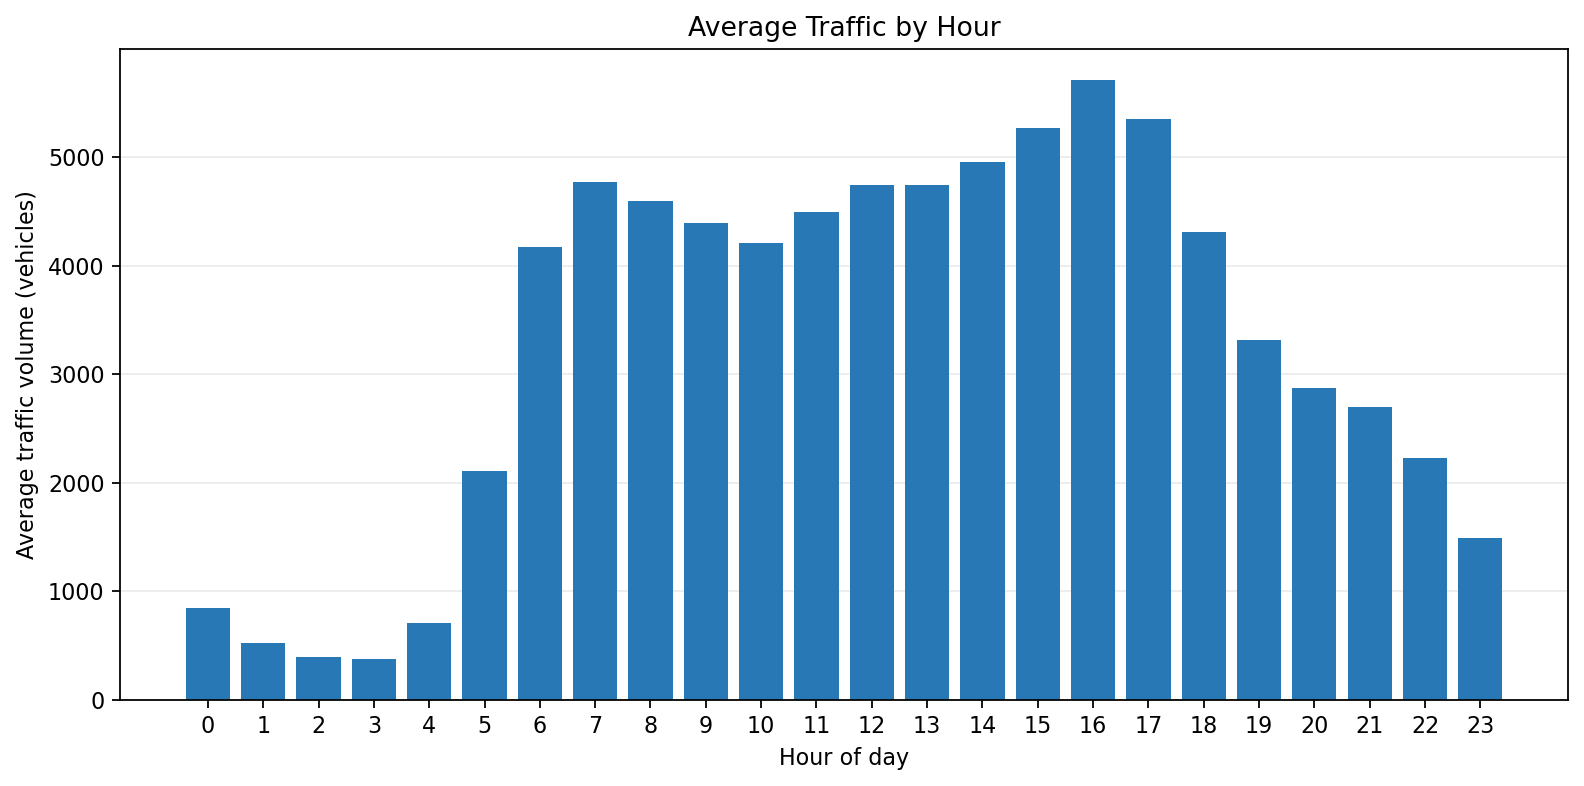

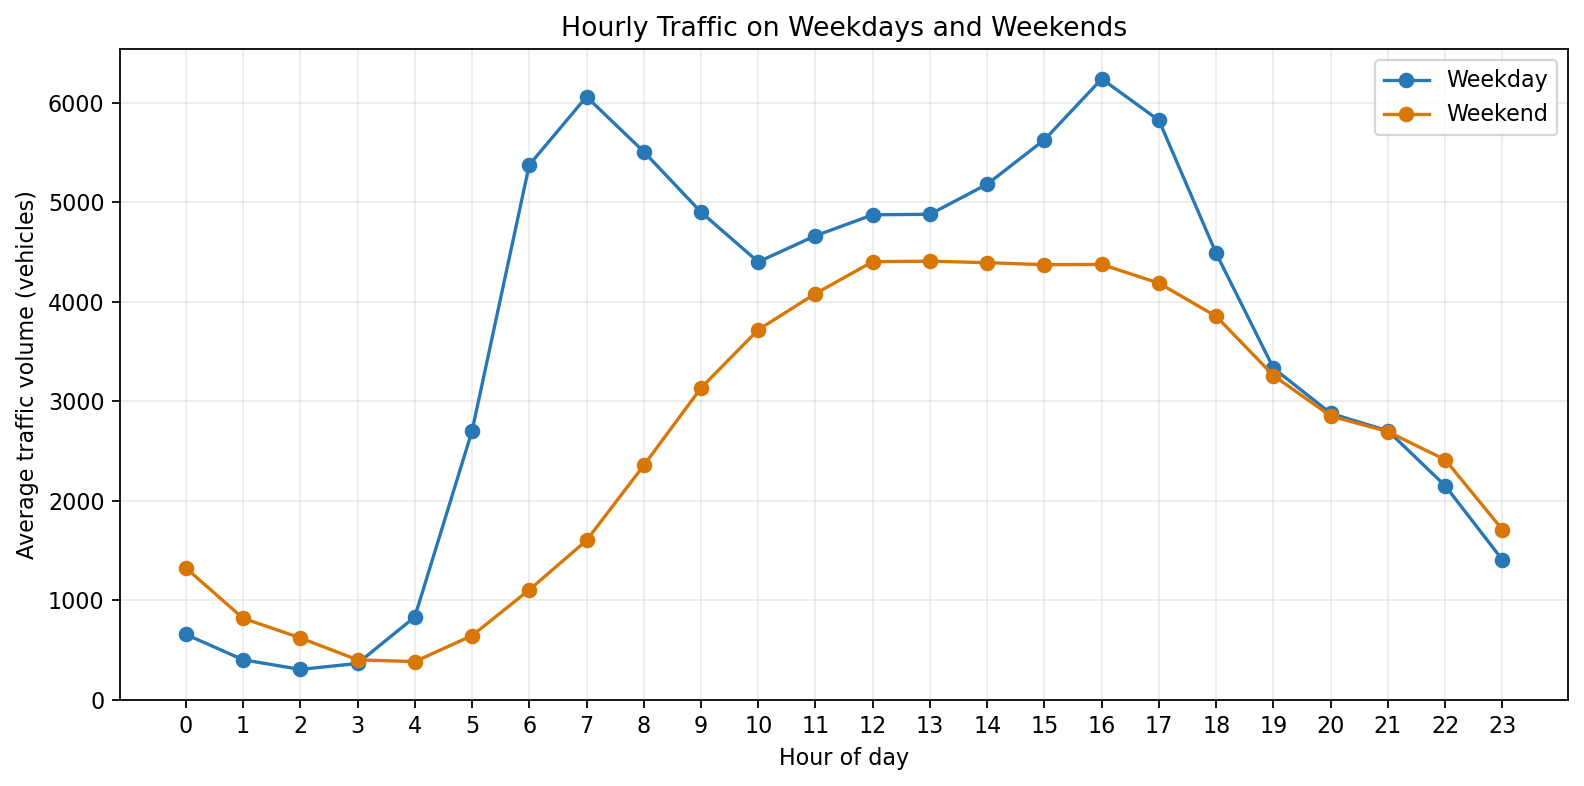

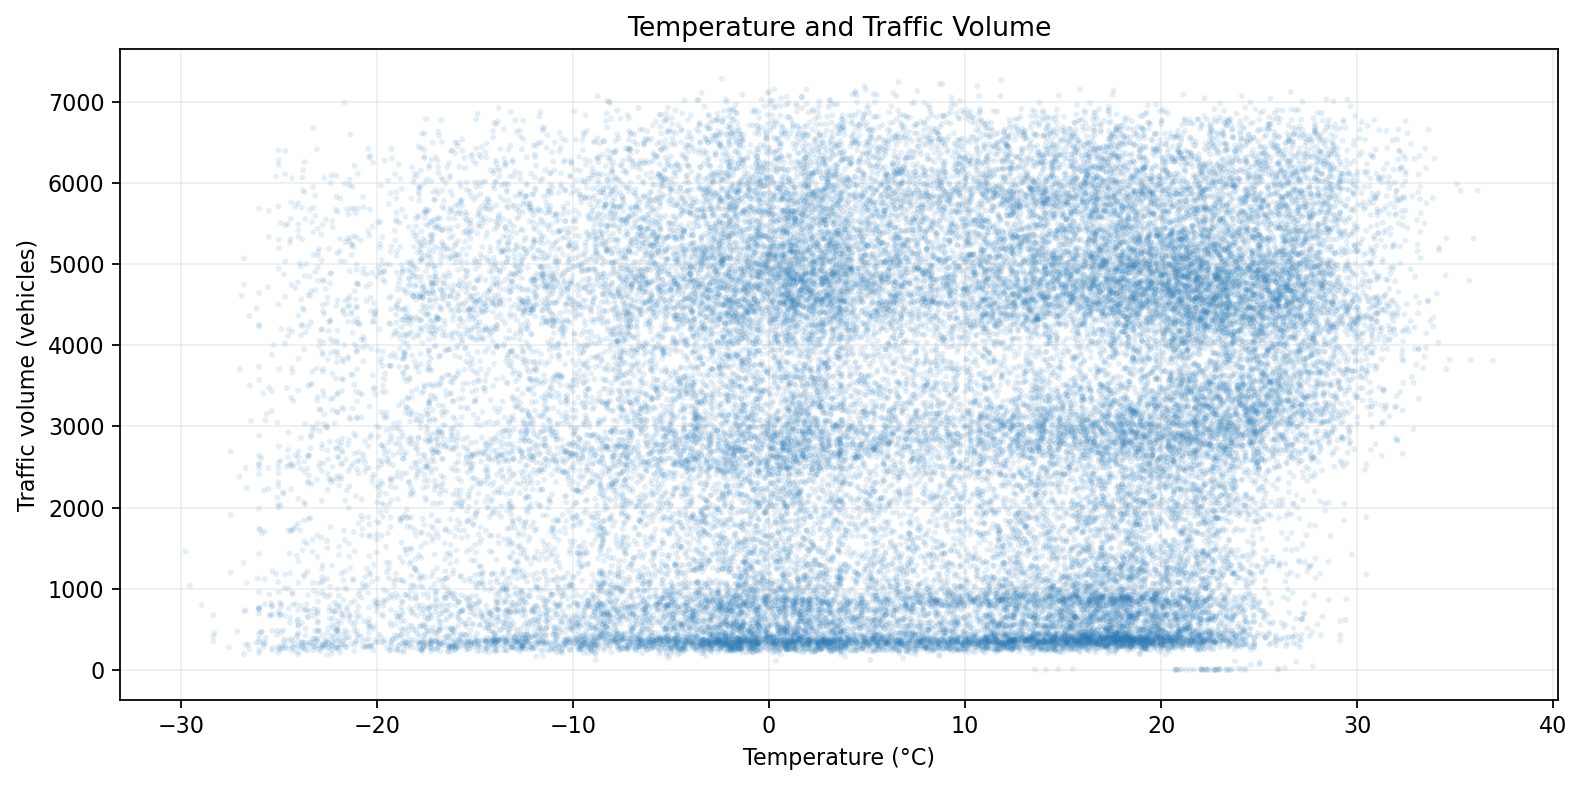

In [13]:
from IPython.display import display, Image

for filename in [
    "01_traffic_by_hour.png",
    "02_weekday_weekend.png",
    "03_temperature_traffic.png"
]:
    display(Image(filename=str(project_folder / "figures" / filename)))

In [14]:
%%writefile cli.py
from pathlib import Path
import argparse
import logging
import sys
from datetime import datetime

import pandas as pd

BASE_DIR = Path(__file__).resolve().parent
logger = logging.getLogger(__name__)


class LoggedArgumentParser(argparse.ArgumentParser):
    def error(self, message):
        logger.error("Invalid command: %s", message)
        self.print_usage(sys.stderr)
        self.exit(2, f"Error: {message}\n")


def load_hourly_data():
    path = BASE_DIR / "data" / "processed" / "traffic_features.csv"
    df = pd.read_csv(path, keep_default_na=False)

    required = {"date_time", "traffic_volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    if df.empty:
        raise ValueError("The dataset is empty.")

    df["date_time"] = pd.to_datetime(df["date_time"], errors="raise")
    df["traffic_volume"] = pd.to_numeric(
        df["traffic_volume"], errors="raise"
    )
    if df[list(required)].isna().any().any():
        raise ValueError("Missing dates or traffic volumes.")

    # Average records sharing a timestamp so each observed hour counts once.
    hourly = (
        df.groupby("date_time", as_index=False)["traffic_volume"]
        .mean()
        .sort_values("date_time")
    )
    logger.info("Loaded %d unique timestamps", len(hourly))
    return hourly


def main(argv=None):
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        handlers=[
            logging.StreamHandler(),
            logging.FileHandler(
                BASE_DIR / "pipeline.log", mode="a", encoding="utf-8"
            ),
        ],
        force=True,
    )

    arguments = sys.argv[1:] if argv is None else argv
    logger.info("CLI invoked | arguments=%s", arguments)

    parser = LoggedArgumentParser(description="Traffic data queries")
    commands = parser.add_subparsers(dest="command", required=True)

    date_parser = commands.add_parser("date", help="Traffic on one date")
    date_parser.add_argument("day", help="Date in YYYY-MM-DD format")

    high_parser = commands.add_parser(
        "high", help="Highest traffic above a threshold"
    )
    high_parser.add_argument("--threshold", type=float, default=5500)
    high_parser.add_argument("--limit", type=int, default=10)

    commands.add_parser(
        "compare", help="Compare weekday and weekend traffic"
    )

    args = parser.parse_args(arguments)
    logger.info("Command=%s | parameters=%s", args.command, vars(args))

    try:
        if args.command == "date":
            try:
                selected_date = datetime.strptime(args.day, "%Y-%m-%d")
            except ValueError:
                raise ValueError("Use a valid date in YYYY-MM-DD format.")
            if selected_date.strftime("%Y-%m-%d") != args.day:
                raise ValueError("Use YYYY-MM-DD, for example 2017-01-01.")

        if args.command == "high":
            if not (0 <= args.threshold < float("inf")):
                raise ValueError("Threshold must be finite and non-negative.")
            if args.limit < 1:
                raise ValueError("Limit must be at least 1.")

        hourly = load_hourly_data()

        if args.command == "date":
            result = hourly.loc[
                hourly["date_time"].dt.date == selected_date.date()
            ]
            if result.empty:
                print(f"No observations found for {args.day}.")
            else:
                print(result.round(2).to_string(index=False))
                print(f"\nObserved hours: {len(result)}")
                print(
                    "Average traffic: "
                    f"{result['traffic_volume'].mean():.2f}"
                )

        elif args.command == "high":
            matching = hourly.loc[
                hourly["traffic_volume"] > args.threshold
            ]
            result = matching.nlargest(args.limit, "traffic_volume")
            print(f"Matching timestamps: {len(matching)}")
            if result.empty:
                print("No observations exceed this threshold.")
            else:
                print(result.round(2).to_string(index=False))

        else:
            hourly["day_type"] = (
                hourly["date_time"].dt.dayofweek.ge(5)
                .map({False: "Weekday", True: "Weekend"})
            )
            result = (
                hourly.groupby("day_type")
                .agg(
                    observed_hours=("traffic_volume", "size"),
                    average_traffic=("traffic_volume", "mean"),
                )
                .reindex(["Weekday", "Weekend"])
            )
            print(result.round(2).to_string())

        logger.info("Command completed successfully: %s", args.command)
        return 0

    except (OSError, ValueError, KeyError, pd.errors.ParserError) as exc:
        logger.error("Command failed: %s", exc)
        print(f"Error: {exc}")
        return 1


if __name__ == "__main__":
    raise SystemExit(main())

Writing cli.py


In [15]:
%run cli.py compare

2026-10-10 21:33:30,528 | INFO | __main__ | CLI invoked | arguments=['compare']
2026-10-10 21:33:30,534 | INFO | __main__ | Command=compare | parameters={'command': 'compare'}
2026-10-10 21:33:30,862 | INFO | __main__ | Loaded 40575 unique timestamps
2026-10-10 21:33:30,909 | INFO | __main__ | Command completed successfully: compare


          observed_hours  average_traffic
day_type                                 
Weekday            28979          3557.44
Weekend            11596          2623.93


In [16]:
%run cli.py date 2017-01-01

2026-10-10 21:38:27,848 | INFO | __main__ | CLI invoked | arguments=['date', '2017-01-01']
2026-10-10 21:38:27,854 | INFO | __main__ | Command=date | parameters={'command': 'date', 'day': '2017-01-01'}
2026-10-10 21:38:28,181 | INFO | __main__ | Loaded 40575 unique timestamps
2026-10-10 21:38:28,278 | INFO | __main__ | Command completed successfully: date


          date_time  traffic_volume
2017-01-01 00:00:00          1848.0
2017-01-01 01:00:00          1806.0
2017-01-01 02:00:00          1211.0
2017-01-01 03:00:00           794.0
2017-01-01 04:00:00           500.0
2017-01-01 05:00:00           513.0
2017-01-01 06:00:00           821.0
2017-01-01 07:00:00           950.0
2017-01-01 08:00:00          1284.0
2017-01-01 09:00:00          2279.0
2017-01-01 10:00:00          3592.0
2017-01-01 11:00:00          3500.0
2017-01-01 12:00:00          3364.0
2017-01-01 13:00:00          3252.0
2017-01-01 14:00:00          3431.0
2017-01-01 15:00:00          3585.0
2017-01-01 16:00:00          3594.0
2017-01-01 17:00:00          3133.0
2017-01-01 18:00:00          2955.0
2017-01-01 19:00:00          2412.0
2017-01-01 20:00:00          1981.0
2017-01-01 21:00:00          1777.0
2017-01-01 22:00:00          1438.0
2017-01-01 23:00:00          1043.0

Observed hours: 24
Average traffic: 2127.62


In [17]:
%run cli.py high --threshold 5500 --limit 10

2026-10-10 21:38:41,243 | INFO | __main__ | CLI invoked | arguments=['high', '--threshold', '5500', '--limit', '10']
2026-10-10 21:38:41,257 | INFO | __main__ | Command=high | parameters={'command': 'high', 'threshold': 5500.0, 'limit': 10}
2026-10-10 21:38:41,572 | INFO | __main__ | Loaded 40575 unique timestamps
2026-10-10 21:38:41,609 | INFO | __main__ | Command completed successfully: high


Matching timestamps: 6107
          date_time  traffic_volume
2017-03-09 16:00:00          7280.0
2016-04-21 07:00:00          7260.0
2016-04-22 07:00:00          7241.0
2013-04-30 07:00:00          7217.0
2018-04-12 16:00:00          7213.0
2016-04-20 07:00:00          7192.0
2012-11-14 16:00:00          7189.0
2017-02-23 16:00:00          7154.0
2013-04-18 07:00:00          7150.0
2016-04-26 07:00:00          7149.0


In [18]:
%run cli.py date 2017-13-01

2026-10-10 21:38:51,067 | INFO | __main__ | CLI invoked | arguments=['date', '2017-13-01']
2026-10-10 21:38:51,073 | INFO | __main__ | Command=date | parameters={'command': 'date', 'day': '2017-13-01'}
2026-10-10 21:38:51,076 | ERROR | __main__ | Command failed: Use a valid date in YYYY-MM-DD format.


Error: Use a valid date in YYYY-MM-DD format.


SystemExit: 1